In [2]:
#import libraries
import numpy as np
import cv2
from PIL import Image
import os
import PIL
import glob
import imutils
from matplotlib import pyplot as plt #import matplotlib
i = 0
bust = []
def is_hidden(file):
    return file.startswith('.')
# read files in loop
path_of_the_directory= 'Training_side'
print("Files and directories in a specified path:")
for filename in os.listdir(path_of_the_directory):
    f = os.path.join(path_of_the_directory,filename)
    if os.path.isfile(f) and not is_hidden(f):
      #  print(f)
        imageFilename = f
      #  print (imageFilename)
        fixed_height = 400
        image = Image.open(f)
        height_percent = (fixed_height / float(image.size[1]))
        width_size = int((float(image.size[0]) * float(height_percent)))
        image = image.resize((width_size, fixed_height), PIL.Image.NEAREST)
        image.save('resized_front.jpg')
        img = cv2.imread('resized_front.jpg')
#         cv2.imshow('Image', img)
#         cv2.waitKey(0)
#         cv2.destroyAllWindows()
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #convert colour from BGR to RGB
#         plt.imshow(img)
#         plt.title('image')
#         plt.axis('on')
#         plt.show()
#         
        # define mask
        mask = np.zeros(img.shape[:2],np.uint8)
        bgdModel = np.zeros((1,65),np.float64)
        fgdModel = np.zeros((1,65),np.float64)

        # define rectangle left, top, width, height
        rect = (100,130,100,350)

        # apply grabCut method to extract the foreground
        cv2.grabCut(img,mask,rect,bgdModel,fgdModel,20,cv2.GC_INIT_WITH_RECT)
        mask2 = np.where((mask==2)|(mask==0),0,1).astype('uint8')
        img = img*mask2[:,:,np.newaxis]
        cv2.imwrite('newimage.jpg',img)
        # display the extracted foreground image

       # plt.imshow(img),plt.colorbar(),plt.show()
       # cv2.imshow('Foreground Image',img)
       # cv2.waitKey(0)
        #cv2.destroyAllWindows()
        #Testing - Measurements
# import numpy as np
# import cv2


        im = cv2.imread('newimage.jpg')
        imgray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
        imgray = cv2.medianBlur(imgray, ksize=7)

        ret, thresh = cv2.threshold(imgray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

#         print ("number of countours detected before filtering %d -> "%len(contours))
        new = np.zeros(imgray.shape)

        new = cv2.drawContours(im,contours,len(contours)-1,(255,255,255),10)

        cv2.namedWindow('Display',cv2.WINDOW_NORMAL)
#         cv2.imshow('Display',new)
#         cv2.waitKey()

        mask = np.zeros(imgray.shape,np.uint8)
        cv2.drawContours(mask,[contours[len(contours)-1]],0,255,-1)
        pixelpoints = cv2.findNonZero(mask)
        cv2.imwrite("masked_image.jpg",mask)
        #Masked image
        img = cv2.imread("masked_image.jpg")

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        ret, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
        cv2.bitwise_not(thresh, thresh)

        cnts = cv2.findContours(thresh, cv2.RETR_EXTERNAL,
                        cv2.CHAIN_APPROX_SIMPLE)

        cnts = cnts[0]
        c = max(cnts, key=cv2.contourArea)

        left = tuple(c[c[:, :, 0].argmin()][0])
        right = tuple(c[c[:, :, 0].argmax()][0])

        distance = np.sqrt( (right[0] - left[0])**2 + (right[1] - left[1])**2 )

        x,y,w,h = cv2.boundingRect(c)

        centx = np.sqrt( ((right[0] + left[0])**2)/4)
        centy = np.sqrt( ((right[1] + left[1])**2)/4 )
        print(centx, centy)

        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.circle(img, left, 5, (0, 0, 255), -1)
        cv2.circle(img, right, 5, (0, 0, 255), -1)
        cv2.circle(img, (int(centx), int(centy)), 5, (0, 0, 255), -1)
        cv2.line(img, left, right, (255,0,0), 2)
        cv2.drawContours(img, [c], -1, (0,255,0), 2)
        cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
        #cv2.putText(img,'Distance: '+str(distance),(10,30), font, 1, (0,0,0),2, cv2.LINE_AA)
#         cv2.imshow('img', img)
#         cv2.waitKey()
        #cv2.imwrite('bulbresult.png', img)
        #Box points
    # import the necessary packages
#         from imutils import paths
#         import numpy as np
#         import imutils
#         from matplotlib import pyplot as plt 
#         import cv2
        img = cv2.imread('masked_image.jpg')
        #img = cv2.imread('newimage_side.jpg')
        def find_marker(img):
            # convert the image to grayscale, blur it, and detect edges
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.GaussianBlur(gray, (5, 5), 0)
            edged = cv2.Canny(gray, 35, 125)
            # find the contours in the edged image and keep the largest one;
            # we'll assume that this is our piece of paper in the image
            cnts = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
            cnts = imutils.grab_contours(cnts)
            c = max(cnts, key = cv2.contourArea)
            cv2.imshow('Image',gray )
            cv2.waitKey(0)
            cv2.destroyAllWindows()
            # compute the bounding box of the of the paper region and return it
            mrker=cv2.minAreaRect(c)
            box = cv2.boxPoints(mrker)
            box = np.int64(box)
            print(box)
            pic=cv2.drawContours(edged,[box], 0, (0, 0, 255), 2)
            cv2.imshow('Image',pic)
            cv2.waitKey(0)
            cv2.destroyAllWindows()
            return cv2.minAreaRect(c)
        helo=find_marker(img)
        print(helo)
        box = cv2.boxPoints(helo)
        box = np.int64(box)
#         print(box)
        cv2.drawContours(img,[box], 0, (0, 0, 255), 1)
#         pltbox = plt.imshow(img)
#         cv2.waitKey(0)
#         cv2.destroyAllWindows()
#         plt.show()
        x,y,w,h = box
        print(x, y, w, h)
        measure = w[0]-h[0]
        bust.append (measure)
#
        print(bust[i])
        i = i+1
print ("Side measurements completed")
#script_path = 'Contour_trial.ipynb'
#os.system(f'python {script_path}')
#!python Contour_trial.ipynb --imageFileName {"Front image/Jenny_front.jpg"} 

Files and directories in a specified path:
149.0 199.5
[[ 88 133]
 [158 127]
 [173 296]
 [103 302]]
((130.9291229248047, 214.963623046875), (170.456787109375, 70.42552185058594), 85.15599822998047)
[ 88 133] [158 127] [173 296] [103 302]
70
149.0 199.5
[[161 162]
 [165 162]
 [165 166]
 [161 166]]
((163.0, 164.0), (4.0, 4.0), 90.0)
[161 162] [165 162] [165 166] [161 166]
4
149.0 199.5
[[ 94 397]
 [117 127]
 [198 133]
 [176 404]]
((146.61724853515625, 265.5931091308594), (82.04893493652344, 271.3095703125), 4.763640880584717)
[ 94 397] [117 127] [198 133] [176 404]
22
Side measurements completed


In [37]:


#imageFileName = input("enter the name of the image file: ") #enter complete path of the image for which the size has to be found

# fixed_height = 400
# image = Image.open(imageFileName)
# height_percent = (fixed_height / float(image.size[1]))
# width_size = int((float(image.size[0]) * float(height_percent)))
# image = image.resize((width_size, fixed_height), PIL.Image.NEAREST)
# image.save('resized_front.jpg')
# img = cv2.imread('resized_front.jpg')
# cv2.imshow('Image', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

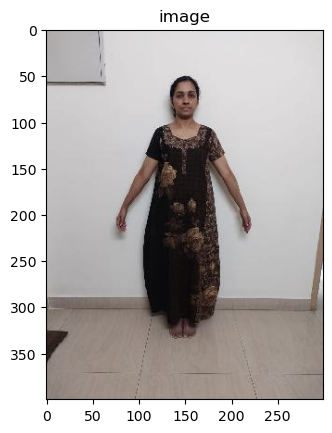

In [38]:
# from matplotlib import pyplot as plt #import matplotlib

# img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #convert colour from BGR to RGB
# plt.imshow(img)
# plt.title('image')
# plt.axis('on')
# plt.show()

In [ ]:
# from PIL import Image
# import os
# import PIL
# import glob

# # define mask
# mask = np.zeros(img.shape[:2],np.uint8)
# bgdModel = np.zeros((1,65),np.float64)
# fgdModel = np.zeros((1,65),np.float64)

# # define rectangle left, top, width, height
# rect = (100,130,100,350)

# # apply grabCut method to extract the foreground
# cv2.grabCut(img,mask,rect,bgdModel,fgdModel,20,cv2.GC_INIT_WITH_RECT)
# mask2 = np.where((mask==2)|(mask==0),0,1).astype('uint8')
# img = img*mask2[:,:,np.newaxis]
# cv2.imwrite('newimage.jpg',img)
# # display the extracted foreground image

# plt.imshow(img),plt.colorbar(),plt.show()
# cv2.imshow('Foreground Image',img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [ ]:
# #Testing - Measurements
# import numpy as np
# import cv2


# im = cv2.imread('newimage.jpg')
# imgray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
# imgray = cv2.medianBlur(imgray, ksize=7)

# ret, thresh = cv2.threshold(imgray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
# contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

# print ("number of countours detected before filtering %d -> "%len(contours))
# new = np.zeros(imgray.shape)

# new = cv2.drawContours(im,contours,len(contours)-1,(255,255,255),10)

# cv2.namedWindow('Display',cv2.WINDOW_NORMAL)
# cv2.imshow('Display',new)
# cv2.waitKey()

# mask = np.zeros(imgray.shape,np.uint8)
# cv2.drawContours(mask,[contours[len(contours)-1]],0,255,-1)
# pixelpoints = cv2.findNonZero(mask)
# cv2.imwrite("masked_image.jpg",mask)

# print(len(pixelpoints))
# print("type of pixelpoints is %s" %type(pixelpoints))


In [ ]:
# #Masked image
# img = cv2.imread("masked_image.jpg")

# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# ret, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
# cv2.bitwise_not(thresh, thresh)

# cnts = cv2.findContours(thresh, cv2.RETR_EXTERNAL,
#                 cv2.CHAIN_APPROX_SIMPLE)

# cnts = cnts[0]
# c = max(cnts, key=cv2.contourArea)

# left = tuple(c[c[:, :, 0].argmin()][0])
# right = tuple(c[c[:, :, 0].argmax()][0])

# distance = np.sqrt( (right[0] - left[0])**2 + (right[1] - left[1])**2 )

# x,y,w,h = cv2.boundingRect(c)

# centx = np.sqrt( ((right[0] + left[0])**2)/4)
# centy = np.sqrt( ((right[1] + left[1])**2)/4 )
# print(centx, centy)

# font = cv2.FONT_HERSHEY_SIMPLEX
# cv2.circle(img, left, 5, (0, 0, 255), -1)
# cv2.circle(img, right, 5, (0, 0, 255), -1)
# cv2.circle(img, (int(centx), int(centy)), 5, (0, 0, 255), -1)
# cv2.line(img, left, right, (255,0,0), 2)
# cv2.drawContours(img, [c], -1, (0,255,0), 2)
# cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
# #cv2.putText(img,'Distance: '+str(distance),(10,30), font, 1, (0,0,0),2, cv2.LINE_AA)
# cv2.imshow('img', img)
# cv2.waitKey()
# #cv2.imwrite('bulbresult.png', img)

In [ ]:
# #Box points
# # import the necessary packages
# from imutils import paths
# import numpy as np
# import imutils
# from matplotlib import pyplot as plt 
# import cv2
# img = cv2.imread('masked_image.jpg')
# #img = cv2.imread('newimage_side.jpg')
# def find_marker(img):
#     # convert the image to grayscale, blur it, and detect edges
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     gray = cv2.GaussianBlur(gray, (5, 5), 0)
#     edged = cv2.Canny(gray, 35, 125)
#     # find the contours in the edged image and keep the largest one;
#     # we'll assume that this is our piece of paper in the image
#     cnts = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
#     cnts = imutils.grab_contours(cnts)
#     c = max(cnts, key = cv2.contourArea)
#     cv2.imshow('Image',gray )
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()
#     # compute the bounding box of the of the paper region and return it
#     mrker=cv2.minAreaRect(c)
#     box = cv2.boxPoints(mrker)
#     box = np.int64(box)
#     print(box)
#     pic=cv2.drawContours(edged,[box], 0, (0, 0, 255), 2)
#     cv2.imshow('Image',pic)
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()
#     return cv2.minAreaRect(c)
# helo=find_marker(img)
# print(helo)
# box = cv2.boxPoints(helo)
# box = np.int64(box)
# print(box)
# cv2.drawContours(img,[box], 0, (0, 0, 255), 1)
# pltbox = plt.imshow(img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# plt.show()
# x,y,w,h = box
# print(x, y, w, h)
# waist = w[0]-h[0]
# print(waist)